In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/gan_checkpoint_10_epochs/pytorch/default/1/gan_checkpoint.pth
/kaggle/input/api-key/kaggle.json


In [2]:
import json
import os

with open("/kaggle/input/api-key/kaggle.json") as f:
    token = json.load(f)

os.makedirs("/root/.config/kaggle", exist_ok=True)

with open("/root/.config/kaggle/kaggle.json", "w") as f:
    json.dump(token, f)

In [3]:
!kaggle datasets download -d jessicali9530/celeba-dataset

Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
License(s): other
 94%|███████████████████████████████████▊  | 1.25G/1.33G [00:01<00:00, 1.22GB/s]
100%|██████████████████████████████████████| 1.33G/1.33G [00:01<00:00, 1.22GB/s]


In [4]:
import zipfile
with zipfile.ZipFile("celeba-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("celeba")

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import torch.nn.parallel
import matplotlib.pyplot as plt
from torch.utils.tensorboard import SummaryWriter

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

2025-07-17 18:26:41.729461: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752776801.934292      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752776801.987870      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


/kaggle/input/gan_checkpoint_10_epochs/pytorch/default/1/gan_checkpoint.pth
/kaggle/input/api-key/kaggle.json


In [15]:
data_root="/kaggle/working/celeba"

workers = 2

batch_size = 128

image_size = 64

n_channel = 3

n_z_noise = 100

n_feature_generator = 64

epochs = 35

lr = 0.002

beta1 = 0.5

ngpu = 1

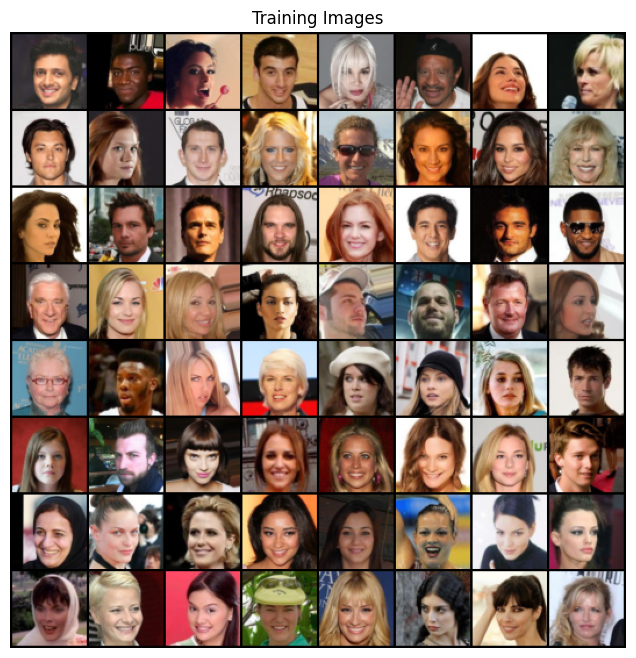

In [16]:
dataset=datasets.ImageFolder(root=data_root,
                            transform=transforms.Compose([
                                transforms.Resize(image_size),
                                transforms.CenterCrop(image_size),
                                transforms.ToTensor(),
                                transforms.Normalize((0.5,0.5,0.5) , (0.5,0.5,0.5)),
                            ]))

dataloader=torch.utils.data.DataLoader(dataset , batch_size=batch_size,
                                       shuffle=True,num_workers=workers)

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

real_batch=next(iter(dataloader))
plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Training Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(device)[:64], padding=2, normalize=True).cpu(),(1,2,0)))
plt.show()

In [9]:
class Generator(nn.Module):
    def __init__(self,ngpu):
        '''
        Initialize the Generator class
        '''
        super(Generator , self).__init__()
        self.ngpu=ngpu
        # Generator architecture
        self.main=nn.Sequential(
            # input is Z , going into convolutional transpose
            nn.ConvTranspose2d(n_z_noise , n_feature_generator * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(n_feature_generator * 8),
            nn.ReLU(True),

            # state size : (ngf*8) x 4 x 4 -> (64*8) x 4 x 4 
            nn.ConvTranspose2d(n_feature_generator * 8, n_feature_generator * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(n_feature_generator * 4),
            nn.ReLU(True),

            # state size : (ngf*4) x 8 x 8 -> (64*4) x 8 x 8 
            nn.ConvTranspose2d( n_feature_generator * 4, n_feature_generator * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(n_feature_generator * 2),
            nn.ReLU(True),

            # state size : (ngf*2) x 16 x 16 -> (64*2) x 16 x 16 
            nn.ConvTranspose2d( n_feature_generator * 2, n_feature_generator, 4, 2, 1, bias=False),
            nn.BatchNorm2d(n_feature_generator),
            nn.ReLU(True), 
            
            # state size : (ngf) x 32 x 32 -> (64) x 32 x 32 
            nn.ConvTranspose2d( n_feature_generator, n_channel, 4, 2, 1, bias=False),
            nn.Tanh()

            # state size : n_channel x 64 x 64 -> 3 x 64 x 64
        )

    def forward(self, input : torch.Tensor) -> torch.Tensor :
        '''
        Forward pass for the generator

        Parameters : 
            input : A noise tensor of shape n_z_noise
        
        Returns : 
            torch.Tensor : a generated image of shape 3 x 64 x 64
        '''
        return self.main(input)

In [10]:
class Discriminator(nn.Module): 
    def __init__(self , ngpu):
        super(Discriminator , self).__init__()
        self.ngpu=ngpu

        self.main=nn.Sequential(

            nn.Conv2d(n_channel , n_feature_generator , 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2 , inplace=True),

            nn.Conv2d(n_feature_generator, n_feature_generator * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(n_feature_generator * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(n_feature_generator * 2, n_feature_generator * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(n_feature_generator * 4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(n_feature_generator * 4, n_feature_generator * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(n_feature_generator * 8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(n_feature_generator * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()           
        )

    def forward(self , input):
        return self.main(input)

In [17]:
checkpoint=torch.load("/kaggle/input/gan_checkpoint_10_epochs/pytorch/default/1/gan_checkpoint.pth")

dis_net=Discriminator(ngpu).to(device)
gen_net=Generator(ngpu).to(device)

dis_net.load_state_dict(checkpoint['dis_state_dict'])
gen_net.load_state_dict(checkpoint['gen_state_dict'])

<All keys matched successfully>

In [18]:
criterion=nn.BCELoss()

fixed_input_noise = torch.randn(64, n_z_noise, 1, 1, device=device)

real_label = 1
fake_label = 0

optimizer_dis = optim.Adam(dis_net.parameters(), lr=lr, betas=(beta1, 0.999))
optimizer_gen = optim.Adam(gen_net.parameters(), lr=lr, betas=(beta1, 0.999))

optimizer_dis.load_state_dict(checkpoint['optimizer_dis'])
optimizer_gen.load_state_dict(checkpoint['optimizer_gen'])

In [19]:
print(dis_net)
print(gen_net)

Discriminator(
  (main): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (12): Sigmoid()
  )
)
Generator(
  (main): Sequentia

In [20]:
img_list=[]
gen_losses=[]
dis_losses=[]
iters=0

writer_real=SummaryWriter(f"logs/real")
writer_fake=SummaryWriter(f"logs/fake")


print("Starting Training Loop....")

for epoch in range(11,epochs):

    for i , data in enumerate(dataloader , 0):

        dis_net.zero_grad()

        real_to_cpu = data[0].to(device)
        b_size=real_to_cpu.size(0)
        label=torch.full((b_size,), real_label, dtype=torch.float, device=device)

        output=dis_net(real_to_cpu).view(-1)

        errorD_real = criterion(output, label)

        errorD_real.backward()
        D_x=output.mean().item()

        noise = torch.randn(b_size, n_z_noise, 1, 1, device=device)

        fake=gen_net(noise)
        label.fill_(fake_label)

        output = dis_net(fake.detach()).view(-1)

        errorD_fake = criterion(output, label)

        errorD_fake.backward()
        optimizer_dis.step()

        D_G_z1= output.mean().item()

        errorD=errorD_fake + errorD_real

        optimizer_dis.step()

        gen_net.zero_grad()
        label.fill_(real_label)

        output = dis_net(fake).view(-1)
        errorG = criterion(output, label)

        errorG.backward()
        D_G_z2 = output.mean().item()

        optimizer_gen.step()

        if i%50==0:
            print('[%d/%d][%d/%d]\tLoss_D: %.4f\tLoss_G: %.4f\tD(x): %.4f\tD(G(z)): %.4f / %.4f'
                  % (epoch, epochs, i, len(dataloader),
                     errorD.item(), errorG.item(), D_x, D_G_z1, D_G_z2))
            
            gen_losses.append(errorG.item())
            dis_losses.append(errorD.item())
            
            if (iters % 500 == 0) or ((epoch == epochs-1) and (i == len(dataloader)-1)):
                with torch.no_grad():
                    fake = gen_net(fixed_input_noise).detach().cpu()
                img_list.append(vutils.make_grid(fake, padding=2, normalize=True))

            img_grid_real = vutils.make_grid(real_to_cpu[:32],normalize=True)
            img_grid_fake = vutils.make_grid(fake[:32],normalize=True)

            writer_real.add_image("Real", img_grid_real, global_step=iters)
            writer_fake.add_image("Fake", img_grid_fake, global_step=iters)

            iters += 1
        

# Save everything needed for resuming
torch.save({
    'epoch': epoch,
    'gen_state_dict': gen_net.state_dict(),
    'dis_state_dict': dis_net.state_dict(),
    'optimizer_gen': optimizer_gen.state_dict(),
    'optimizer_dis': optimizer_dis.state_dict(),
    'gen_losses': gen_losses,
    'dis_losses': dis_losses,
    'iters': iters
}, 'gan_checkpoint.pth')



Starting Training Loop....
[11/35][0/1583]	Loss_D: 0.2117	Loss_G: 4.0108	D(x): 0.8498	D(G(z)): 0.0100 / 0.0479
[11/35][50/1583]	Loss_D: 0.1990	Loss_G: 4.2508	D(x): 0.9072	D(G(z)): 0.0711 / 0.0293
[11/35][100/1583]	Loss_D: 0.2219	Loss_G: 4.9395	D(x): 0.8599	D(G(z)): 0.0168 / 0.0316
[11/35][150/1583]	Loss_D: 0.1027	Loss_G: 5.3873	D(x): 0.9681	D(G(z)): 0.0574 / 0.0095
[11/35][200/1583]	Loss_D: 0.2879	Loss_G: 8.1688	D(x): 0.9712	D(G(z)): 0.1685 / 0.0012
[11/35][250/1583]	Loss_D: 0.0896	Loss_G: 5.4737	D(x): 0.9637	D(G(z)): 0.0399 / 0.0127
[11/35][300/1583]	Loss_D: 0.1079	Loss_G: 5.7086	D(x): 0.9509	D(G(z)): 0.0460 / 0.0074
[11/35][350/1583]	Loss_D: 0.1062	Loss_G: 4.8327	D(x): 0.9503	D(G(z)): 0.0396 / 0.0187
[11/35][400/1583]	Loss_D: 0.0702	Loss_G: 5.1522	D(x): 0.9587	D(G(z)): 0.0218 / 0.0146
[11/35][450/1583]	Loss_D: 0.5603	Loss_G: 8.0327	D(x): 0.9965	D(G(z)): 0.3153 / 0.0013
[11/35][500/1583]	Loss_D: 0.1793	Loss_G: 7.5641	D(x): 0.9831	D(G(z)): 0.1169 / 0.0015
[11/35][550/1583]	Loss_D: 0.12